##### Ссылка на репозиторий и этот ноутбук с файлами: github: https://github.com/randnull/genotec/blob/main/hw_4_phsasing_and_ibd.ipynb

Домашнее задание 4

## Для каждой пары геномов найдите IBD сегменты. Можете использовать фазирование и поиск IBD-сегментов. Можете использовать поиск half-IBD сегментов без фазирования.

Будем делать фазирование (разделение на галотипы) и поиск IBD-сегментов. Для этого будем использовать утилиту [beagle](https://faculty.washington.edu/browning/beagle/beagle.html), предварительно переконвертировав данные в формат vcf с помощью plink

```bash
plink --bfile data/biengi --recode vcf bgz --out input
```

```bash
java -Xmx4g -jar tools/beagle.27Feb25.75f.jar gt=data/input.vcf.gz out=phased
```

Теперь сделаем поиск ibd-сегментов с помощью утилиты [hap-ibd](https://github.com/browning-lab/hap-ibd)

```bash
java -Xmx4g -jar hap-ibd.jar gt=phased.vcf.gz out=ibd
```

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm


In [54]:
ibd = pd.read_csv("data/ibd.ibd/ibd.ibd", sep="\t", header=None)

In [55]:
ibd.columns = ["id1", "hap1", "id2", "hap2", "chrom", "start", "end", "cm"]

In [92]:
ibd

,id1,hap1,id2,hap2,chrom,start,end,cm
0,4461875520_R01C01_4461875520_R01C01,1,4459273543_R01C01_4459273543_R01C01,2,1,166934629,167847509,2.282
1,4461875537_R02C01_4461875537_R02C01,2,4257735807_A_4257735807_A,1,1,166944948,167851169,2.283
2,4461875537_R02C01_4461875537_R02C01,2,4257735608_B_4257735608_B,1,1,166944948,167851169,2.283
3,4461875537_R02C01_4461875537_R02C01,2,4159588416_A_4159588416_A,1,1,166944948,167851169,2.283
4,4461875806_R01C01_4461875806_R01C01,1,4481622840_R02C01_4481622840_R02C01,1,1,166944948,167851169,2.283
...,...,...,...,...,...,...,...,...
815673,4461875636_R01C01_4461875636_R01C01,1,4461875843_R01C01_4461875843_R01C01,1,22,44064812,44863637,2.866
815674,4461875636_R01C01_4461875636_R01C01,1,4475687243_R01C01_4475687243_R01C01,2,22,44064812,44863637,2.866
815675,4459273506_R02C02_4459273506_R02C02,1,4459273513_R01C02_4459273513_R01C02,2,22,44027510,44863637,2.873
815676,4461875758_R02C02_4461875758_R02C02,2,4459273506_R02C02_4459273506_R02C02,1,22,44027510,44863637,2.873


Мы видим такой результат:

id первого человека (4461875520_R01C01_4461875520_R01C01), его галотип, id второго, его галотип а дальше идет номер хромосомы, позиция старта и конца и длина совпадающего участка в сМ

## Вычислите среднее количество общей суммы IBD / half-IBD сегментов между популяциями. Визуализируйте в виде Heatmap. 

Для этого возьмем данные по популяциям из изначального файла и смерджим их с полученной выше таблицей

In [57]:
pedind = pd.read_csv("data/biengi/biengi.pedind", sep="\t", header=None)
pedind.columns = ["fam_id", "id", "x", "y", "sex", "population"]
pedind["full_id"] = pedind["fam_id"] + "_" + pedind["id"]
pedind

,fam_id,id,x,y,sex,population,full_id
0,4461875510_R01C01,4461875510_R01C01,0,0,1,Karel,4461875510_R01C01_4461875510_R01C01
1,4461875510_R01C02,4461875510_R01C02,0,0,1,Karel,4461875510_R01C02_4461875510_R01C02
2,4461875510_R02C01,4461875510_R02C01,0,0,1,Karel,4461875510_R02C01_4461875510_R02C01
3,4461875513_R02C02,4461875513_R02C02,0,0,1,Karel,4461875513_R02C02_4461875513_R02C02
4,4461875513_R01C02,4461875513_R01C02,0,0,1,Karel,4461875513_R01C02_4461875513_R01C02
...,...,...,...,...,...,...,...
889,4252441600_B,4252441600_B,0,0,2,Yakut,4252441600_B_4252441600_B
890,4252441601_A,4252441601_A,0,0,2,Yakut,4252441601_A_4252441601_A
891,4252441601_B,4252441601_B,0,0,2,Yakut,4252441601_B_4252441601_B
892,4252441619_A,4252441619_A,0,0,2,Yakut,4252441619_A_4252441619_A


Сгруппируем данные по парам индивидам по длине общей совпадающей части

In [58]:
pop_lookup = pedind[["full_id", "population"]]
pair_sum = ibd.groupby(["id1", "id2"], as_index=False)["cm"].sum()
pair_sum = (
    pair_sum
    .merge(pop_lookup.rename(columns={"full_id": "id1", "population": "id1_population"}), on="id1", how="left")
    .merge(pop_lookup.rename(columns={"full_id": "id2", "population": "id2_population"}), on="id2", how="left")
)
pair_sum


,id1,id2,cm,id1_population,id2_population
0,4159588086_A_4159588086_A,4159588086_B_4159588086_B,4.280,Russian_NSK,Russian_NSK
1,4159588086_A_4159588086_A,4159588297_A_4159588297_A,11.815,Russian_NSK,Russian_NSK
2,4159588086_A_4159588086_A,4159588297_B_4159588297_B,15.385,Russian_NSK,Russian_NSK
3,4159588086_A_4159588086_A,4159588392_A_4159588392_A,7.708,Russian_NSK,Russian_NSK
4,4159588086_A_4159588086_A,4159588392_B_4159588392_B,9.203,Russian_NSK,Russian_NSK
...,...,...,...,...,...
248493,4493906459_R01C02_4493906459_R01C02,4481622897_R02C01_4481622897_R02C01,20.703,Kirgiz,Tuva
248494,4493906459_R01C02_4493906459_R01C02,4481622897_R02C02_4481622897_R02C02,15.025,Kirgiz,Tuva
248495,4493906459_R01C02_4493906459_R01C02,4481622899_R01C01_4481622899_R01C01,12.615,Kirgiz,Tuva
248496,4493906459_R01C02_4493906459_R01C02,4481622899_R01C02_4481622899_R01C02,27.188,Kirgiz,Tuva


In [60]:
pair_sum

,id1,id2,cm,id1_population,id2_population
0,4159588086_A_4159588086_A,4159588086_B_4159588086_B,4.280,Russian_NSK,Russian_NSK
1,4159588086_A_4159588086_A,4159588297_A_4159588297_A,11.815,Russian_NSK,Russian_NSK
2,4159588086_A_4159588086_A,4159588297_B_4159588297_B,15.385,Russian_NSK,Russian_NSK
3,4159588086_A_4159588086_A,4159588392_A_4159588392_A,7.708,Russian_NSK,Russian_NSK
4,4159588086_A_4159588086_A,4159588392_B_4159588392_B,9.203,Russian_NSK,Russian_NSK
...,...,...,...,...,...
248493,4493906459_R01C02_4493906459_R01C02,4481622897_R02C01_4481622897_R02C01,20.703,Kirgiz,Tuva
248494,4493906459_R01C02_4493906459_R01C02,4481622897_R02C02_4481622897_R02C02,15.025,Kirgiz,Tuva
248495,4493906459_R01C02_4493906459_R01C02,4481622899_R01C01_4481622899_R01C01,12.615,Kirgiz,Tuva
248496,4493906459_R01C02_4493906459_R01C02,4481622899_R01C02_4481622899_R01C02,27.188,Kirgiz,Tuva


Как мы видим, осталось только смерджить по популяциям, чтобы получить итоговый результат (только отсортируем их в одном формате, чтобы потом не мучаться с маппингом из-за не верхнетреугольной матрицы)

In [100]:
sort_a = np.minimum(pair_sum["id1_population"], pair_sum["id2_population"])
sort_b = np.maximum(pair_sum["id1_population"], pair_sum["id2_population"])
pair_sum["sort_a"], pair_sum["sort_b"] = sort_a, sort_b
sum_by_pop = pair_sum.groupby(["sort_a", "sort_b"])["cm"].sum().unstack(fill_value=0.0)
sum_by_pop

sort_b,Abkhaz,Adygei,Bashkir,Belarus,Buryat,Chechen,Cherkes,Chinese,Chuvash,Kabardin,...,Moldovan,Mordva,Russian_NSK,Russian_STV,Tatar,Tuva,Udmurt,Ukrainian,Uzbek,Yakut
sort_a,,,,,,,,,,,,,,,,,,,,,
Abkhaz,6718.872,7938.894,1233.032,1569.687,773.488,1493.579,9286.805,27.537,944.168,8310.787,...,1590.485,1837.290,1776.561,1892.467,1741.204,765.741,987.134,1212.421,1328.734,526.121
Adygei,0.000,21175.482,2075.093,2414.336,1356.681,1598.403,13554.033,80.754,1790.194,12464.492,...,2216.494,2705.846,2744.356,2932.234,2458.231,1482.153,1733.229,2047.612,1741.640,1066.675
Bashkir,0.000,0.000,41141.345,3657.337,8395.481,906.204,2282.415,545.973,10143.064,2353.301,...,3205.143,4919.049,6561.455,6276.831,9307.167,7876.549,7879.621,3705.781,3573.097,8196.602
Belarus,0.000,0.000,0.000,5329.854,1393.927,1130.035,2669.192,63.013,4819.597,2581.408,...,7653.389,8789.316,10641.998,11258.277,6006.479,1306.914,3397.819,9704.144,2136.520,764.561
Buryat,0.000,0.000,0.000,0.000,141893.645,696.456,2336.086,1601.169,4161.184,2143.864,...,1404.705,2523.238,3420.633,3253.596,3809.176,30428.158,3273.831,1574.928,7062.568,57485.709
Chechen,0.000,0.000,0.000,0.000,0.000,8788.949,2329.360,19.665,883.333,2663.844,...,1164.530,1338.196,1368.212,1285.012,1029.874,702.485,963.503,1046.107,890.379,578.785
Cherkes,0.000,0.000,0.000,0.000,0.000,0.000,12394.841,158.176,1980.094,14620.058,...,2385.326,2948.460,3181.731,3245.711,2589.228,2059.931,1695.680,2311.368,1816.611,2047.876
Chinese,0.000,0.000,0.000,0.000,0.000,0.000,0.000,409.889,252.034,134.667,...,83.178,135.950,173.343,113.068,221.922,1201.057,173.367,87.849,598.709,1254.625
Chuvash,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,26860.356,2103.057,...,4069.084,6888.415,10089.075,8919.544,15572.156,4898.649,8762.513,5719.556,2933.706,4137.100


По таблице видно, что мы получили матрицу где между популяциями находится общее число ibd-сегментов

Теперь нормируем на размер популяции

Для одинаковых популяций получается:

$count = len_a * (len_a - 1) / 2$ (просто упорядоченные пары)

а для разных их произведение:

$count = len_a * len_b$


In [ ]:
populations = sorted(pedind["population"].unique())
sizes = pedind["population"].value_counts().to_dict()

heat = pd.DataFrame(0.0, index=populations, columns=populations, dtype=float)
for a in populations:
    for b in populations:
        x, y = (a, b) if a <= b else (b, a)
        s = sum_by_pop.loc[x, y]
        n = sizes[a] * (sizes[a] - 1) / 2 if a == b else sizes[a] * sizes[b]
        heat.loc[a, b] = s / n

Рисовать будет по лог-шкале, так как данные внутри одной популяции очевидно сильно больше, чем между соседними

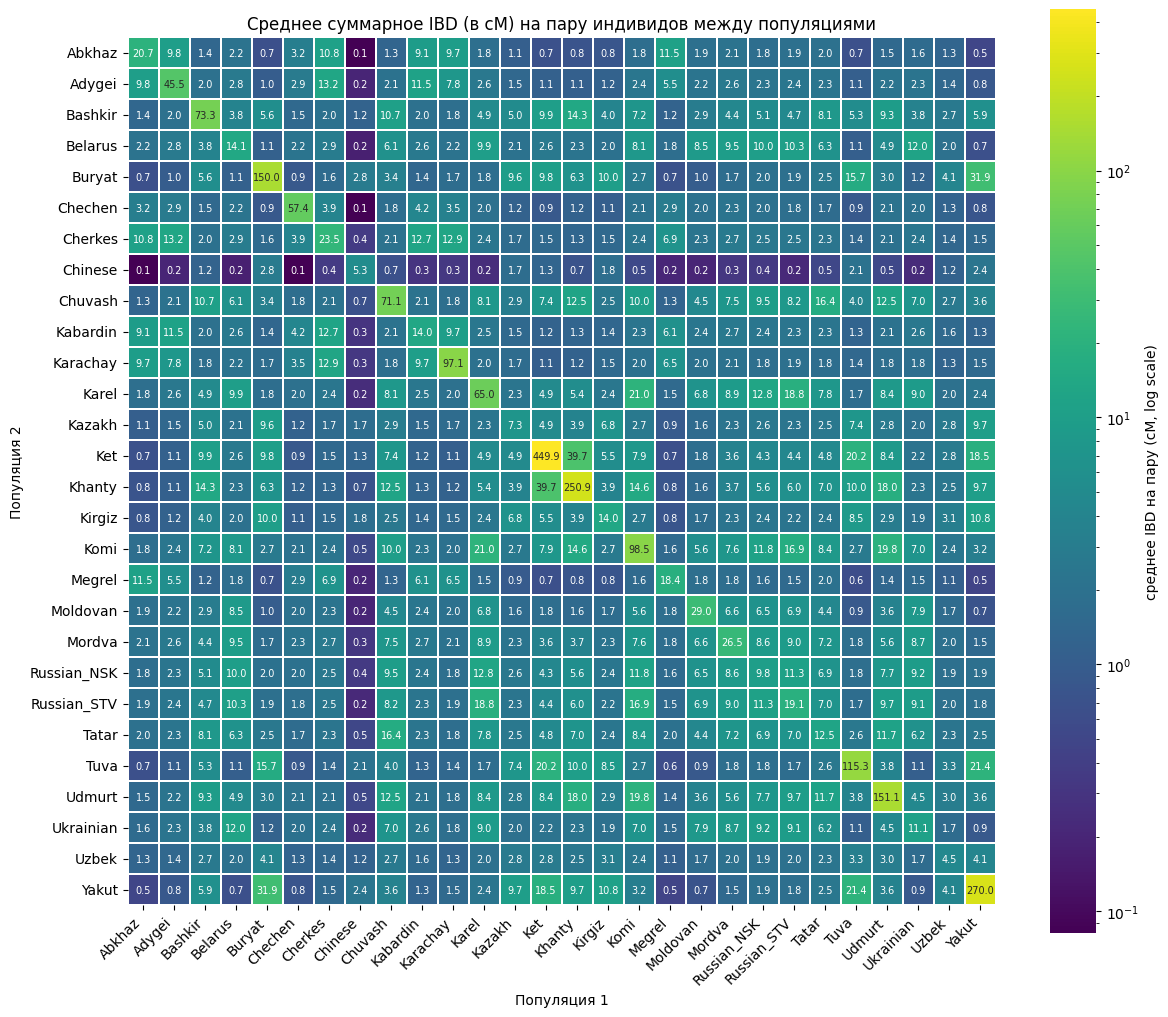

In [117]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    heat,
    cmap="viridis",
    norm=LogNorm(),
    square=True,
    cbar_kws={"label": "среднее IBD на пару (cM, log scale)"},
    linewidths=0.1, linecolor="white",
    annot=True, fmt=".1f", annot_kws={"size": 7},
)
plt.title("Среднее суммарное IBD (в сМ) на пару индивидов между популяциями")
plt.xlabel("Популяция 1")
plt.ylabel("Популяция 2")
plt.xticks(rotation=45, ha="right")
plt.show()

## Проанализируйте и опишите полученный результат. Сравните с PCA

Сначала посмотрим на главную диагональ, где отображены популяции между собой.

Видно, что внутри некоторых популяций среднее число IBD очень велико (Ket, Khanty и Yakut), что может указывать на небольшое число населения в близких областях и/или прохождения популяции через бутылочное горлышко (недавнее).

У Китая, например, среднее число между своей популяцией достаточно низкое - 5.3. Можно предположить, что это из-за огромного размера популяции и большой территории заселения.

Китай также сильнее всего отличается от всех других популяций.

Остальные результаты ожидаемые, где-то связи больше (Bashkir и Khanty), то есть есть общие близкие родственники у многих среди этих популяций. Где-то связи мало - Yakut и Belarus (что тоже логично, так как территория проживания совершенна разная)

Теперь добавим PCA и сравним с ним

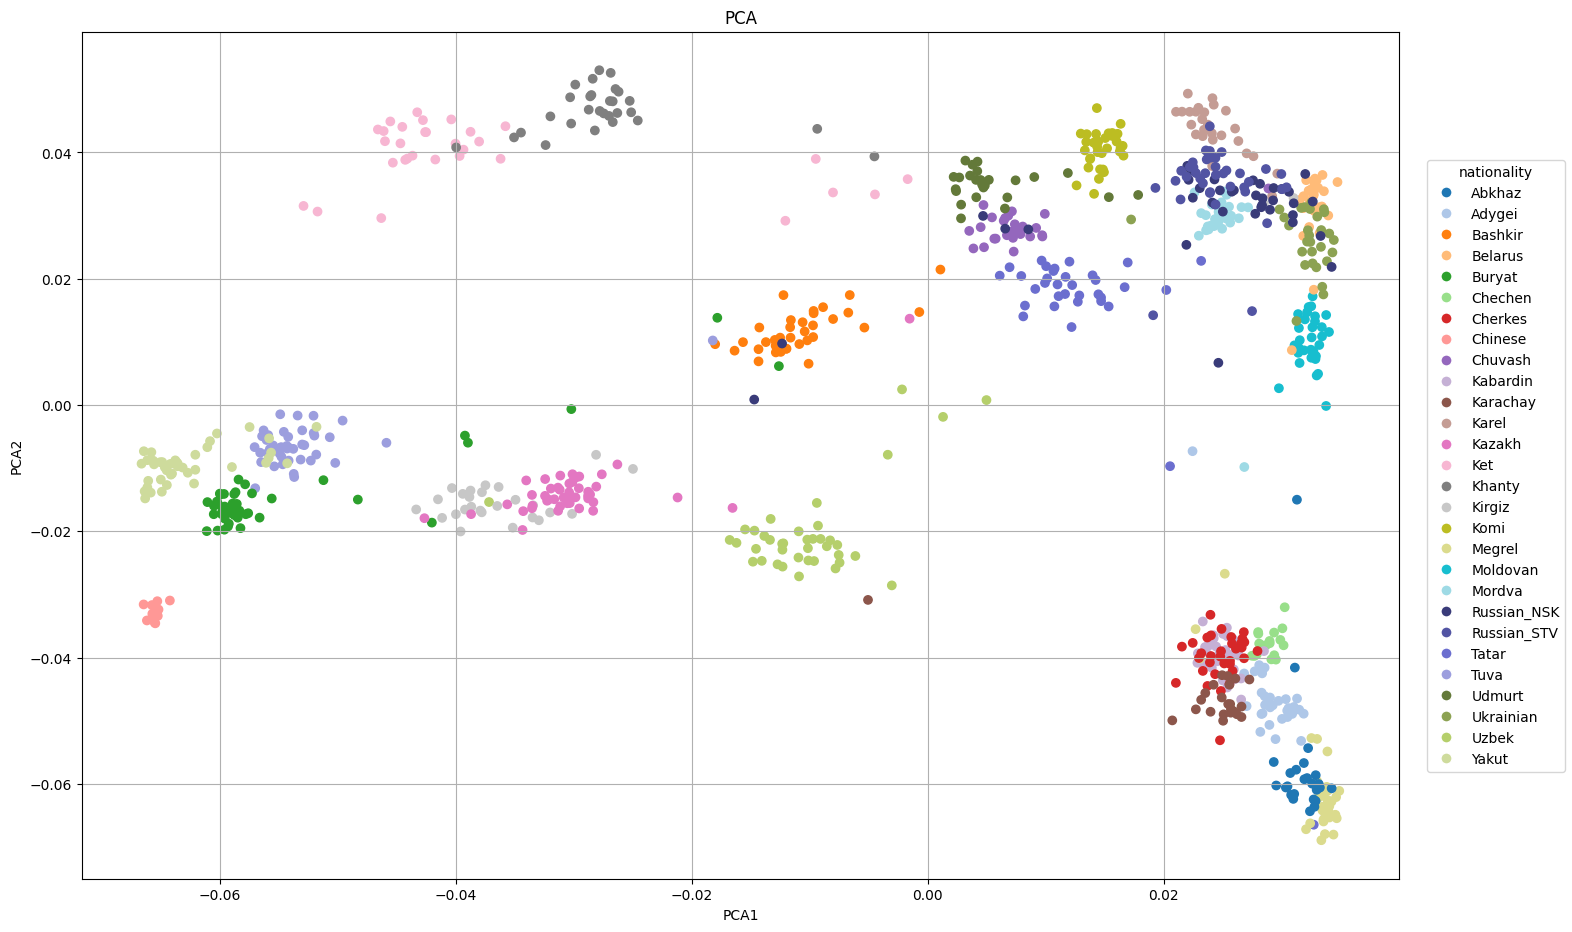

Если смотреть на Китай, то графики не совсем согласуются. Да - Китай отдельно от всех остальных, но внутри самой китайской выборки все индивиды близки друг к другу (проблема интерпритации PCA, последствия ld-prunning).

Якуты близки между собой, и правда, что рядом с Якутами Башкиры и Тувинцы.

В остальном графики средне более-менее согласуются между собой.